# Notebook 02 — Deseasonalization

**Inputs:** ENTSOE API (prices DE_LU, 2023-2025), Open-Meteo API (temperature Berlin, 2023-2025)  
**Outputs:** `data/seasonality/german_panel.csv`, `data/seasonality/german_panel_2026.csv`, `data/seasonality/german_temp_fourier_*`

### Import Prices


In [1]:
a=1

In [2]:
from pathlib import Path
import os
import pandas as pd
from dotenv import load_dotenv

CWD = Path.cwd().resolve()
if (CWD / "germany" / "germany23+24+25").exists():
    PROJECT_ROOT = CWD
    CODE_DIR = CWD / "germany" / "germany23+24+25"
elif CWD.name == "germany23+24+25":
    CODE_DIR = CWD
    PROJECT_ROOT = CWD.parent.parent
else:
    raise FileNotFoundError("Run this notebook from the repo root or from germany/germany23+24+25/.")

DATA_DIR = CODE_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(PROJECT_ROOT / ".env")
API_KEY = os.getenv("ENTSOE_API_KEY")
if not API_KEY:
    raise RuntimeError("ENTSOE_API_KEY not found in .env or environment")
api_key = API_KEY
print("key =", api_key[:5], "...")

key = d1f8b ...


In [3]:
import pandas as pd
from entsoe import EntsoePandasClient

client = EntsoePandasClient(api_key=API_KEY)
ZONE = "DE_LU"
CALIBRATION_START = pd.Timestamp("2023-01-01", tz="UTC")
CALIBRATION_END_EXCLUSIVE = pd.Timestamp("2026-01-01", tz="UTC")
OOS_START = pd.Timestamp("2026-01-01", tz="UTC")
OOS_END_EXCLUSIVE = pd.Timestamp("2026-05-01", tz="UTC")
OOS_END_OPENMETEO = (OOS_END_EXCLUSIVE - pd.Timedelta(days=1)).date().isoformat()

start = CALIBRATION_START
end_exclusive = CALIBRATION_END_EXCLUSIVE

prices = client.query_day_ahead_prices(ZONE, start=start, end=end_exclusive)

prices_df = prices.to_frame(name="price_eur_mwh")
prices_df.index.name = "datetime"
prices_df = prices_df.tz_convert("UTC")
prices_df.head()  


,price_eur_mwh
datetime,
2023-01-01 00:00:00+00:00,-1.07
2023-01-01 01:00:00+00:00,-1.47
2023-01-01 02:00:00+00:00,-5.08
2023-01-01 03:00:00+00:00,-4.49
2023-01-01 04:00:00+00:00,-5.40


### Import Temperature


In [4]:
import pandas as pd
import openmeteo_requests
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession(str(CODE_DIR / ".cache"), expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

latitude = 52.52  # Berlin
longitude = 13.405

url = "https://archive-api.open-meteo.com/v1/archive"  

params = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": ["temperature_2m"],
    "timezone": "UTC",                 
    "start_date": CALIBRATION_START.date().isoformat(),
    "end_date": (CALIBRATION_END_EXCLUSIVE - pd.Timedelta(days=1)).date().isoformat(),          
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

hourly = response.Hourly()
temperature_2m = hourly.Variables(0).ValuesAsNumpy()

time_index = pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left",
)

temp_df = pd.DataFrame({"temperature_c": temperature_2m}, index=time_index) #pandas series with datetime index
temp_df.index.name = "datetime"
temp_df.head()



,temperature_c
datetime,
2023-01-01 00:00:00+00:00,15.25
2023-01-01 01:00:00+00:00,15.65
2023-01-01 02:00:00+00:00,15.70
2023-01-01 03:00:00+00:00,15.80
2023-01-01 04:00:00+00:00,15.75


### Deseasonalise temperature : Fourier-based seasonal regression

The temperature series $y_t$ is modeled as the sum of a trend, seasonal components, and a residual:

$$
y_t = T(x_t) + f_{day}(x_t) + f_{year}(x_t) + f_{inter}(x_t) + \varepsilon_t
$$

The trend component is assumed to be linear:

$$
T(x_t) = \beta_0 + \beta_1 x_t
$$

where $x_t$ is the time index (in hours).

Seasonal effects are approximated using truncated Fourier series:

$$
f_P(x_t) =
\sum_{k=1}^{K}
\left[
a_k \cos\left(\frac{2\pi k x_t}{P}\right)
+
b_k \sin\left(\frac{2\pi k x_t}{P}\right)
\right]
$$

Two seasonal components are included:

$$
f_{day}(x_t) \quad (P_{day} = 24)
$$

$$
f_{year}(x_t) \quad (P_{year} = 365.25 \times 24)
$$

To allow the daily cycle to vary during the year, interaction terms are introduced as products of the Fourier bases:

$$
f_{inter}(x_t) =
\sum_{i=1}^{2K_{day}}
\sum_{j=1}^{2K_{year}}
c_{ij}
\, f^{day}_i(x_t) \, f^{year}_j(x_t)
$$

Parameters are estimated by ordinary least squares:

$$
\hat{\beta} = \arg\min_{\beta} \|y - X\beta\|^2
$$

The deseasonalized series is obtained from the residuals:

$$
r_t = y_t - \hat{y}_t
$$      


In [5]:
import numpy as np
import pandas as pd

P_day = 24
P_year = 365.25 * 24
K_day = 3
K_year = 1

# Sort, enforce hourly frequency, fill any missing hours by linear interpolation
temp = temp_df["temperature_c"].sort_index().asfreq("h").interpolate(method="linear")

# Hours elapsed since the start of the series
xt = ((temp.index - temp.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)

def fourier_block(x, period, K):
    omega = 2 * np.pi / period
    cols = []
    for k in range(1, K + 1):
        cols.append(np.cos(k * omega * x))
        cols.append(np.sin(k * omega * x))
    return np.column_stack(cols)

X_intercept_trend = [np.ones_like(xt), xt]
block_day  = fourier_block(xt, P_day,  K_day)
block_year = fourier_block(xt, P_year, K_year)

# Interaction terms: each daily Fourier component × each annual Fourier component
inter_cols = []
for i in range(block_day.shape[1]):
    for j in range(block_year.shape[1]):
        inter_cols.append(block_day[:, i] * block_year[:, j])

block_inter = np.column_stack(inter_cols)

Xt = np.column_stack(X_intercept_trend + [block_day, block_year, block_inter])

betat, *_ = np.linalg.lstsq(Xt, temp.values, rcond=None)
temp_fit   = Xt @ betat
temp_resid = pd.Series(temp.values - temp_fit, index=temp.index, name="temp_deseasoned")

# Build coefficient names for readability
names = ["intercept", "trend"]
for k in range(1, K_day + 1):
    names += [f"day_cos_{k}", f"day_sin_{k}"]
for k in range(1, K_year + 1):
    names += [f"year_cos_{k}", f"year_sin_{k}"]
for i in range(block_day.shape[1]):
    for j in range(block_year.shape[1]):
        names.append(f"inter_{i}_{j}")

coef    = pd.Series(betat, index=names, name="coefficient")
coef_df = coef.reset_index()
coef_df.columns = ["term", "value"]

print(coef)
print(temp_resid.head())

intercept     11.649337
trend         -0.000036
day_cos_1     -2.734695
day_sin_1     -1.389773
day_cos_2      0.546052
day_sin_2      0.000115
day_cos_3      0.117861
day_sin_3      0.072093
year_cos_1    -8.954891
year_sin_1    -2.874872
inter_0_0      1.591469
inter_0_1     -0.300345
inter_1_0      0.749166
inter_1_1     -0.091420
inter_2_0      0.180574
inter_2_1     -0.042053
inter_3_0      0.281879
inter_3_1      0.046580
inter_4_0     -0.371924
inter_4_1      0.051874
inter_5_0     -0.043635
inter_5_1     -0.000112
Name: coefficient, dtype: float64
datetime
2023-01-01 00:00:00+00:00    13.226216
2023-01-01 01:00:00+00:00    13.617181
2023-01-01 02:00:00+00:00    13.684530
2023-01-01 03:00:00+00:00    13.891995
2023-01-01 04:00:00+00:00    14.055971
Freq: h, Name: temp_deseasoned, dtype: float64


In [6]:
import numpy as np, json
from pathlib import Path

SEAS_DIR = DATA_DIR / "seasonality"
SEAS_DIR.mkdir(parents=True, exist_ok=True)

np.save(SEAS_DIR / "german_temp_fourier_betat.npy", betat)
json.dump({
    "P_day":        P_day,
    "P_year":       P_year,
    "K_day":        K_day,
    "K_year":       K_year,
    "train_origin": str(temp.index[0]),
}, open(SEAS_DIR / "german_temp_fourier_params.json", "w"))
print("Saved Fourier coefficients and parameters.")

Saved Fourier coefficients and parameters.


In [7]:
coef_trend = coef[["intercept", "trend"]]
coef_day = coef[[n for n in coef.index if n.startswith("day_")]]
coef_year = coef[[n for n in coef.index if n.startswith("year_")]]
coef_inter = coef[[n for n in coef.index if n.startswith("inter_")]]

print("Trend")
print(coef_trend)

print("\nDay")
print(coef_day)

print("\nYear")
print(coef_year)

print("\nInteractions")
pd.set_option("display.max_rows", None)
print(coef_inter)

Trend
intercept    11.649337
trend        -0.000036
Name: coefficient, dtype: float64

Day
day_cos_1   -2.734695
day_sin_1   -1.389773
day_cos_2    0.546052
day_sin_2    0.000115
day_cos_3    0.117861
day_sin_3    0.072093
Name: coefficient, dtype: float64

Year
year_cos_1   -8.954891
year_sin_1   -2.874872
Name: coefficient, dtype: float64

Interactions
inter_0_0    1.591469
inter_0_1   -0.300345
inter_1_0    0.749166
inter_1_1   -0.091420
inter_2_0    0.180574
inter_2_1   -0.042053
inter_3_0    0.281879
inter_3_1    0.046580
inter_4_0   -0.371924
inter_4_1    0.051874
inter_5_0   -0.043635
inter_5_1   -0.000112
Name: coefficient, dtype: float64


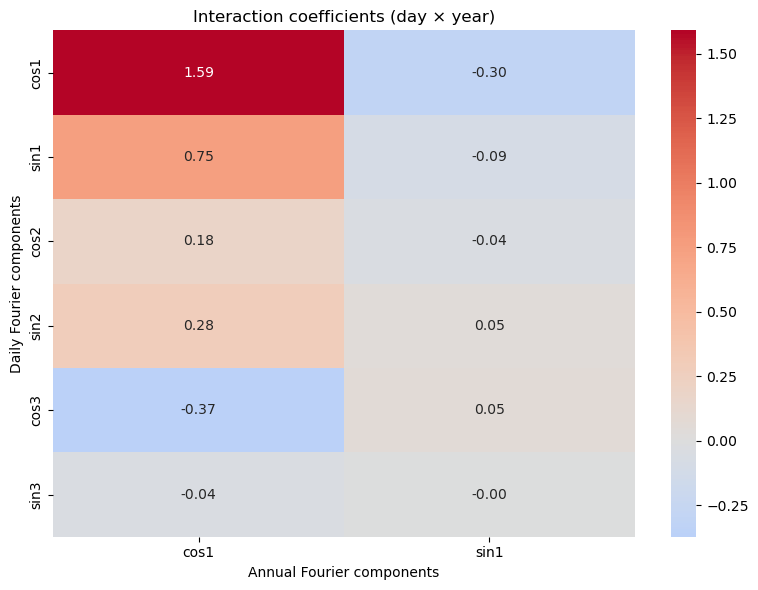

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

n_day  = block_day.shape[1]
n_year = block_year.shape[1]

inter_matrix = np.zeros((n_day, n_year))
k = 0
for i in range(n_day):
    for j in range(n_year):
        inter_matrix[i, j] = coef_inter.iloc[k]
        k += 1

day_labels  = [f"cos{k}" if i % 2 == 0 else f"sin{k}"
               for k in range(1, K_day + 1) for i in range(2)]
year_labels = [f"cos{k}" if i % 2 == 0 else f"sin{k}"
               for k in range(1, K_year + 1) for i in range(2)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    inter_matrix,
    xticklabels=year_labels,
    yticklabels=day_labels,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.xlabel("Annual Fourier components")
plt.ylabel("Daily Fourier components")
plt.title("Interaction coefficients (day × year)")
plt.tight_layout()
plt.show()

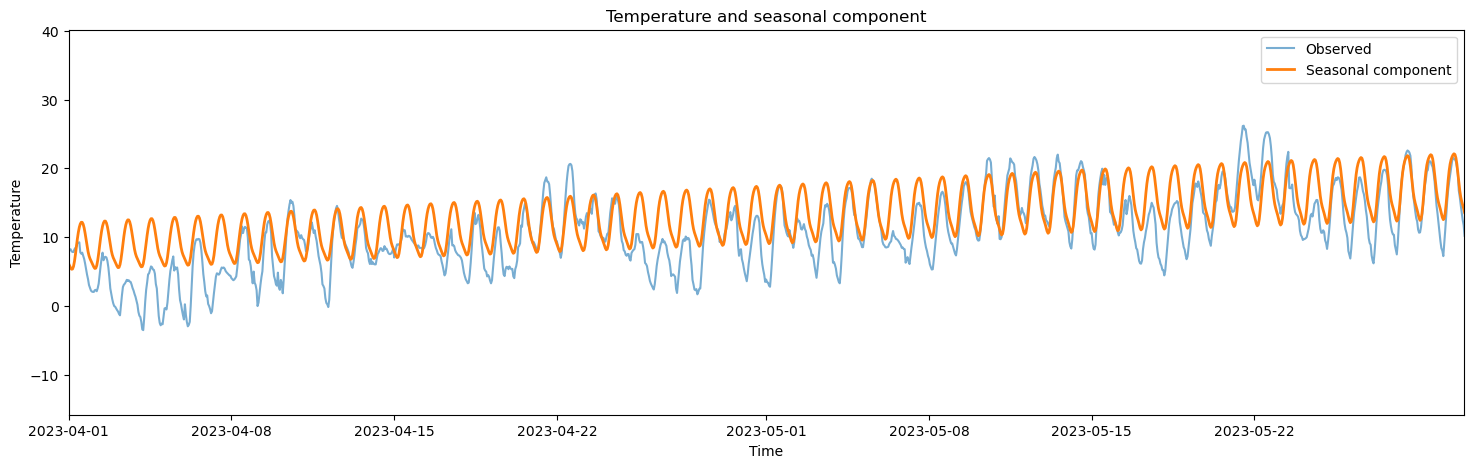

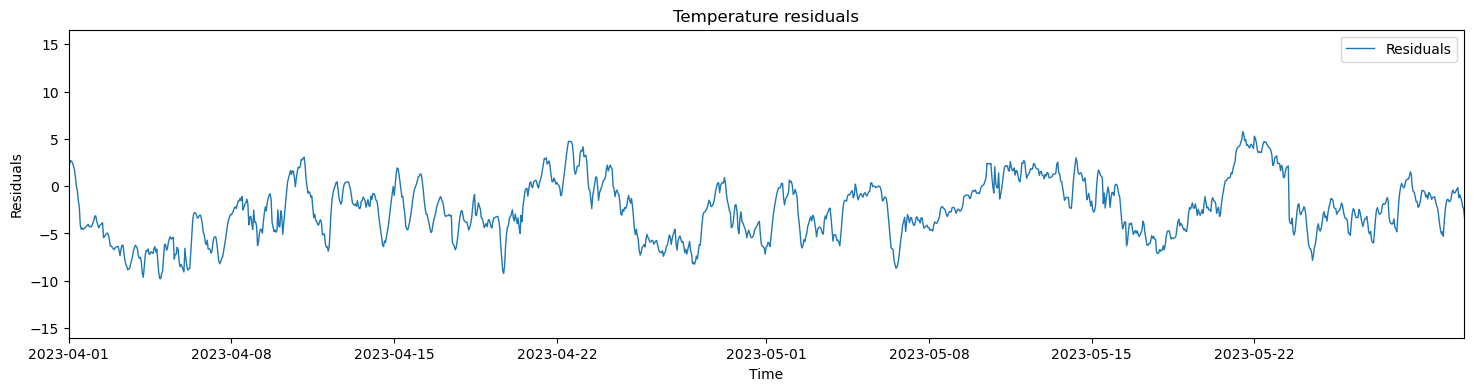

In [9]:
plt.figure(figsize=(18,5))
plt.plot(temp.index, temp.values, alpha=0.6, label="Observed")
plt.plot(temp.index, temp_fit, linewidth=2, label="Seasonal component")
plt.xlim(temp.index[24*30*3], temp.index[24*30*5])  
plt.legend()
plt.title("Temperature and seasonal component")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

plt.figure(figsize=(18,4))
plt.plot(temp_resid.index, temp_resid.values, linewidth=1, label="Residuals")
plt.legend()
plt.xlim(temp.index[24*30*3], temp.index[24*30*5])  
plt.title("Temperature residuals")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.show()

#### Autocorrelation structure — before and after deseasonalization

The ACF of the raw temperature series shows strong periodicity at lags 24 h and 8760 h. After removing the deterministic seasonal component the ACF decays geometrically, confirming that the residual $r_t = y_t - \hat{y}_t$ is a weakly stationary process amenable to CARMA modelling.

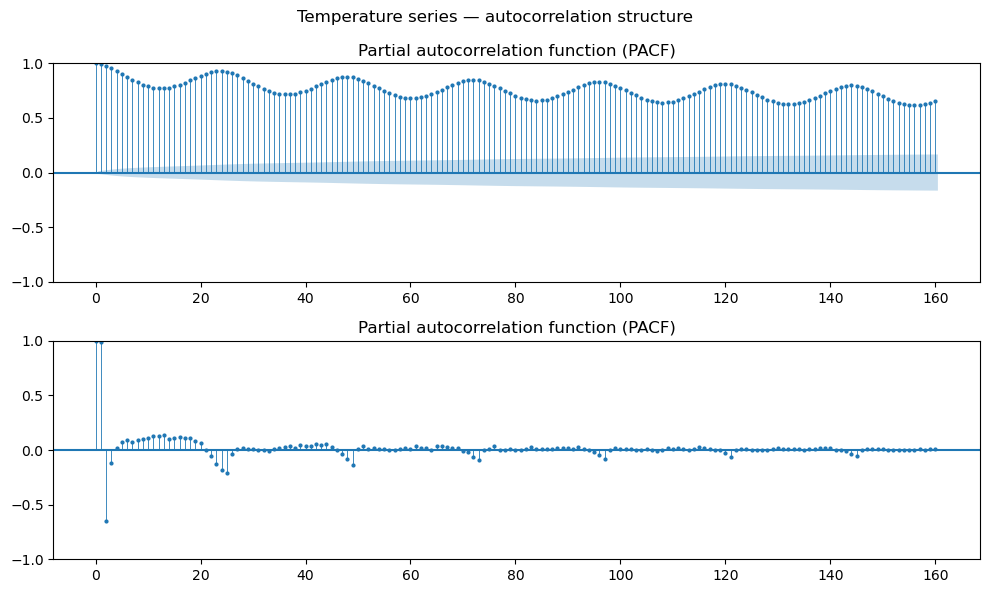

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(10, 6))
fig.suptitle("Temperature series — autocorrelation structure")

plot_acf(temp,  lags=160, ax=axs[0], vlines_kwargs={"linewidth": 0.6}, markersize=2)
axs[0].set_title("Partial autocorrelation function (PACF)")

plot_pacf(temp, lags=160, ax=axs[1], vlines_kwargs={"linewidth": 0.6}, markersize=2)
axs[1].set_title("Partial autocorrelation function (PACF)")

plt.tight_layout()
plt.show()

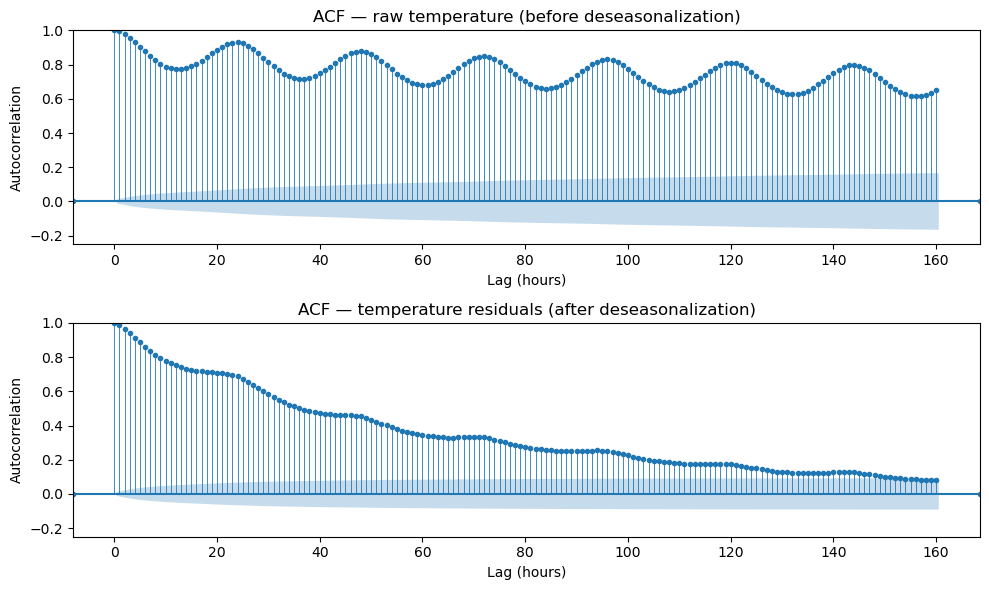

In [11]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(temp, lags=160, ax=axs[0],
         vlines_kwargs={"linewidth": 0.6}, marker='o', markersize=3)
axs[0].set_title("ACF — raw temperature (before deseasonalization)")
axs[0].set_ylabel("Autocorrelation")
axs[0].set_xlabel("Lag (hours)")

plot_acf(temp_resid, lags=160, ax=axs[1],
         vlines_kwargs={"linewidth": 0.6}, marker='o', markersize=3)
axs[1].set_title("ACF — temperature residuals (after deseasonalization)")
axs[1].set_ylabel("Autocorrelation")
axs[1].set_xlabel("Lag (hours)")

axs[0].set_ylim(-0.25, 1)
axs[1].set_ylim(-0.25, 1)

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss

### Residual diagnostics — temperature

Assesses stationarity and distributional properties of the deseasonalized temperature residuals $r_t^Y = y_t - \hat{y}_t^{\text{seas}}$. A histogram and normal QQ-plot test for Gaussianity; summary statistics (mean, standard deviation, skewness, excess kurtosis) quantify departures from normality that motivate the NIG distribution in the Lévy fitting step (notebook 06).

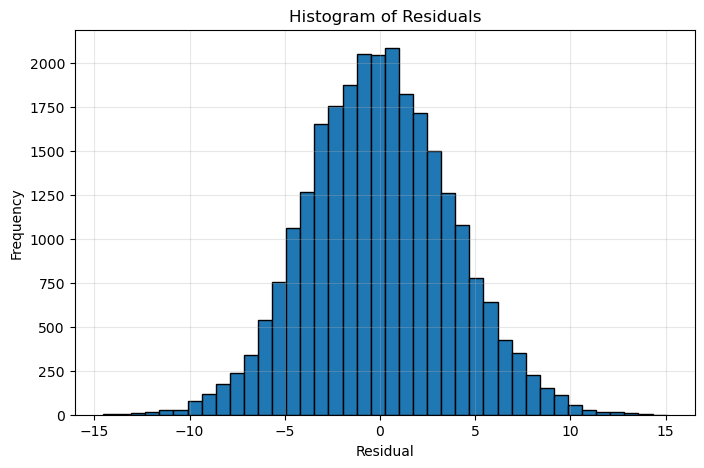

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(temp_resid, bins=40, edgecolor="black")
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

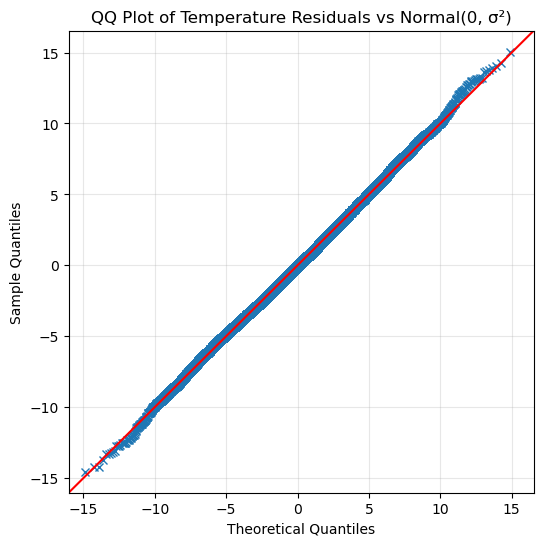

In [14]:
# ensure Series
temp_series = temp_resid.squeeze()

plt.figure(figsize=(6, 6))
qqplot(temp_series,
       dist=norm,
       loc=0,
       scale=np.std(temp_series),
       line='45',
       marker='x',
       ax=plt.gca())

plt.title("QQ Plot of Temperature Residuals vs Normal(0, σ²)")
plt.grid(alpha=0.3)
plt.show()

In [15]:
temp_series = temp_resid.squeeze()
summary_stats_temp = pd.DataFrame({
    "Value": [
        temp_series.count(),
        temp_series.mean(),
        temp_series.std(),
        temp_series.min(),
        temp_series.quantile(0.25),
        temp_series.median(),
        temp_series.quantile(0.75),
        temp_series.max(),
        stats.skew(temp_series, bias=False),
        stats.kurtosis(temp_series, fisher=True, bias=False)
    ]
}, index=[
    "Count",
    "Mean",
    "Std",
    "Min",
    "25%",
    "Median",
    "75%",
    "Max",
    "Skewness",
    "Excess Kurtosis"
])

print("Summary Statistics for Temperature Residuals\n")
print(summary_stats_temp.round(4))

Summary Statistics for Temperature Residuals

                      Value
Count            26304.0000
Mean                -0.0000
Std                  3.7657
Min                -14.5486
25%                 -2.5922
Median              -0.0630
75%                  2.5029
Max                 15.0569
Skewness             0.0713
Excess Kurtosis      0.0705


### Out-of-sample diagnostics — temperature seasonality (2026)

Tests whether the Fourier seasonal model fitted on 2023-2025 generalises to unseen 2026 data (January-April). 
RMSE and MAE are compared against in-sample values; a ratio close to 1 indicates no overfitting. 
Systematic patterns in the 2026 residuals (biased mean, inflated ACF, or heavier tails) would signal structural misspecification.

In [16]:
responses_2026 = openmeteo.weather_api(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": 52.52,
        "longitude": 13.405,
        "hourly": ["temperature_2m"],
        "timezone": "UTC",
        "start_date": OOS_START.date().isoformat(),
        "end_date": OOS_END_OPENMETEO,
    }
)
r26 = responses_2026[0].Hourly()
time_2026 = pd.date_range(
    start=pd.to_datetime(r26.Time(), unit="s", utc=True),
    end=pd.to_datetime(r26.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=r26.Interval()),
    inclusive="left",
)
temp_2026 = (
    pd.Series(r26.Variables(0).ValuesAsNumpy(), index=time_2026, name="temperature_c")
    .sort_index().asfreq("h").interpolate(method="linear")
)
start_str = str(temp_2026.index[0].date())
end_str   = str(temp_2026.index[-1].date())
print(f"2026 temperature (Berlin): {len(temp_2026)} hourly observations ({start_str} to {end_str})")
print(temp_2026.describe().round(3))

2026 temperature (Berlin): 2880 hourly observations (2026-01-01 to 2026-04-30)
count    2880.000
mean        3.792
std         6.467
min       -12.850
25%        -0.950
50%         3.875
75%         8.550
max        21.600
Name: temperature_c, dtype: float64


=== Out-of-sample error metrics ===
      train (2023-25)  test (2026)  ratio (test/train)
RMSE           3.7657       4.3440        1.153600e+00
MAE            2.9994       3.4690        1.156600e+00
Std            3.7657       4.2229        1.121400e+00
Mean          -0.0000      -1.0215        6.255707e+13


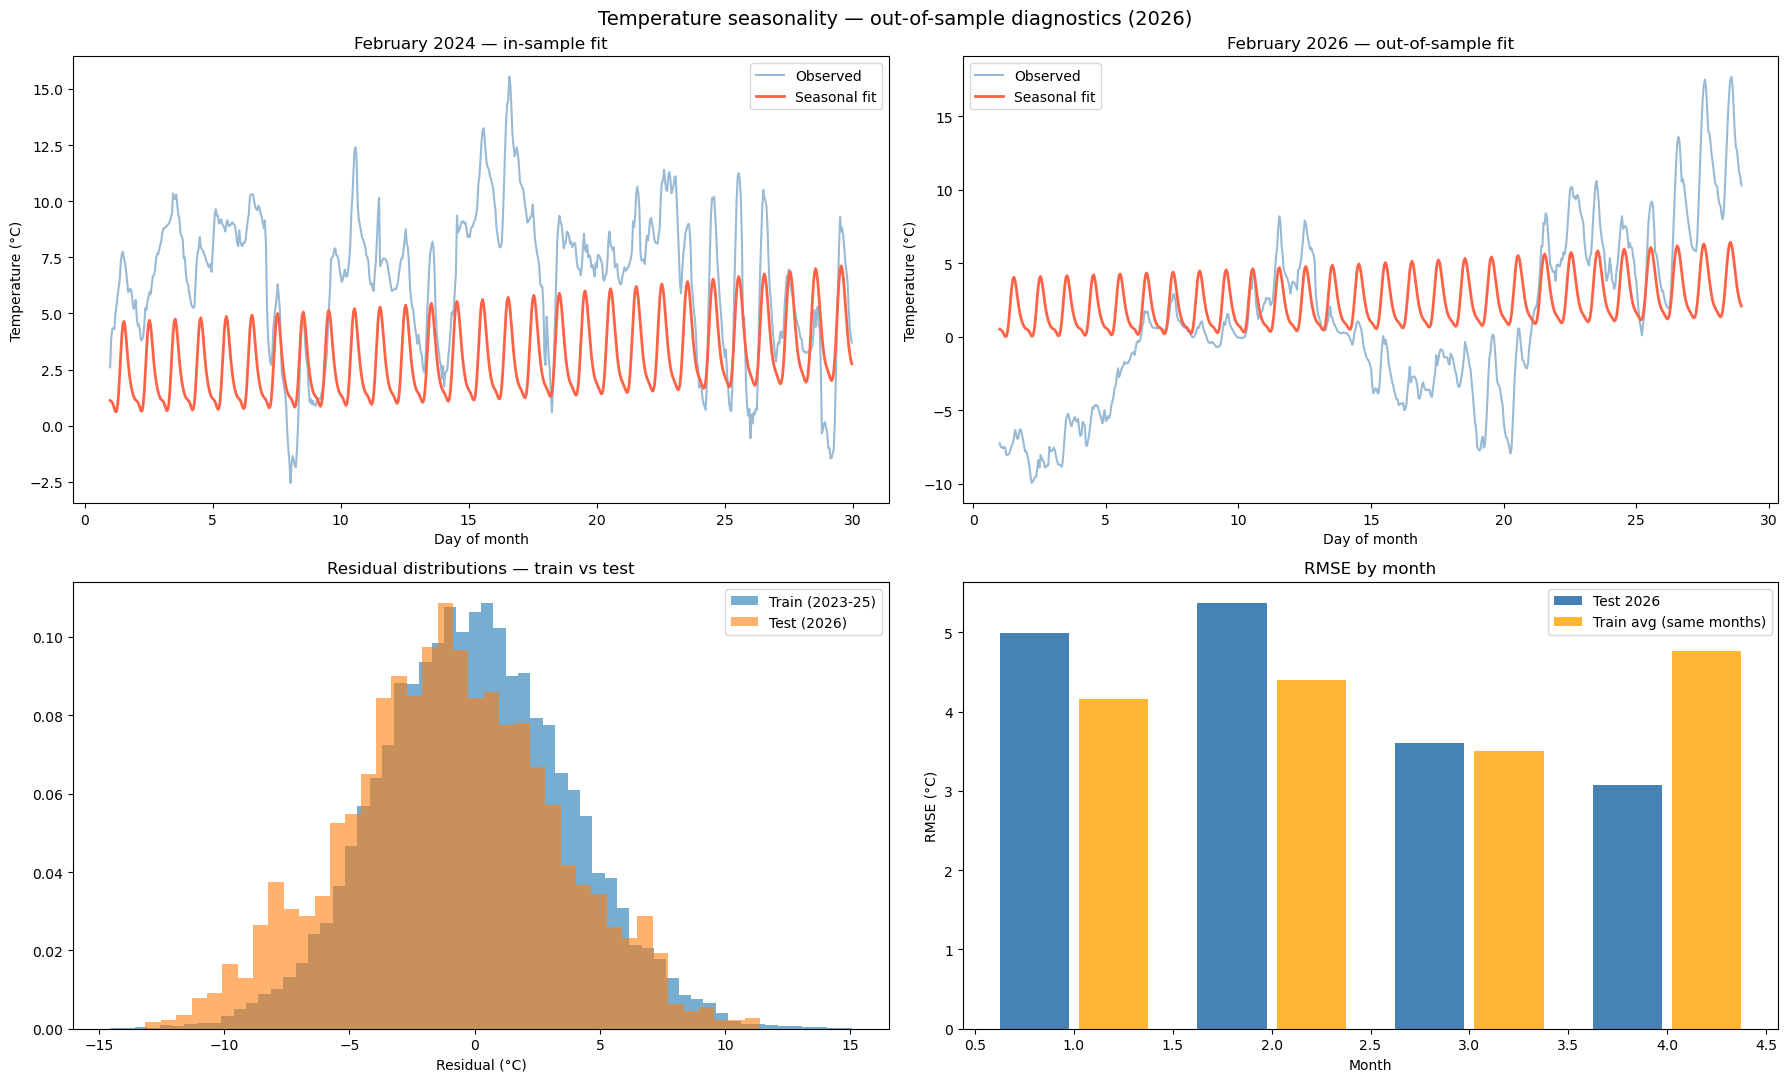

In [17]:
# Build design matrix for 2026 (same time origin and Fourier structure as training)
xt_2026 = ((temp_2026.index - temp.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)

bd26 = fourier_block(xt_2026, P_day,  K_day)
by26 = fourier_block(xt_2026, P_year, K_year)
bi26 = np.column_stack([
    bd26[:, i] * by26[:, j]
    for i in range(bd26.shape[1])
    for j in range(by26.shape[1])
])
Xt26 = np.column_stack([np.ones_like(xt_2026), xt_2026, bd26, by26, bi26])

fit_2026   = Xt26 @ betat
resid_2026 = pd.Series(
    temp_2026.values - fit_2026,
    index=temp_2026.index,
    name="resid_2026",
)

# In-sample Feb 2024 fit
feb24_mask  = (temp.index.month == 2) & (temp.index.year == 2024)
temp_feb24  = temp[feb24_mask]
xt_feb24    = ((temp_feb24.index - temp.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)
bd24 = fourier_block(xt_feb24, P_day,  K_day)
by24 = fourier_block(xt_feb24, P_year, K_year)
bi24 = np.column_stack([
    bd24[:, i] * by24[:, j]
    for i in range(bd24.shape[1])
    for j in range(by24.shape[1])
])
Xt24      = np.column_stack([np.ones_like(xt_feb24), xt_feb24, bd24, by24, bi24])
fit_feb24 = Xt24 @ betat
resid_feb24 = pd.Series(temp_feb24.values - fit_feb24, index=temp_feb24.index, name="resid_feb24")

feb26_mask  = temp_2026.index.month == 2
temp_feb26  = temp_2026[feb26_mask]
fit_feb26   = fit_2026[feb26_mask]
resid_feb26 = resid_2026[feb26_mask]

def _rmse(e): return float(np.sqrt(np.mean(np.asarray(e)**2)))
def _mae(e):  return float(np.mean(np.abs(np.asarray(e))))

metrics_df = pd.DataFrame({
    "train (2023-25)": {
        "RMSE": _rmse(temp_resid),
        "MAE":  _mae(temp_resid),
        "Std":  float(np.asarray(temp_resid).std()),
        "Mean": float(np.asarray(temp_resid).mean()),
    },
    "test (2026)": {
        "RMSE": _rmse(resid_2026),
        "MAE":  _mae(resid_2026),
        "Std":  float(resid_2026.std()),
        "Mean": float(resid_2026.mean()),
    },
})
metrics_df["ratio (test/train)"] = (
    metrics_df["test (2026)"].abs() / metrics_df["train (2023-25)"].abs()
)
print("=== Out-of-sample error metrics ===")
print(metrics_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle("Temperature seasonality — out-of-sample diagnostics (2026)", fontsize=14)

days24 = temp_feb24.index.day + (temp_feb24.index.hour / 24)
days26 = temp_feb26.index.day + (temp_feb26.index.hour / 24)

axes[0, 0].plot(days24, temp_feb24.values, alpha=0.55, label="Observed", color="steelblue")
axes[0, 0].plot(days24, fit_feb24, linewidth=2, label="Seasonal fit", color="tomato")
axes[0, 0].set_title("February 2024 — in-sample fit", fontsize=12)
axes[0, 0].set_xlabel("Day of month"); axes[0, 0].set_ylabel("Temperature (°C)"); axes[0, 0].legend()

axes[0, 1].plot(days26, temp_feb26.values, alpha=0.55, label="Observed", color="steelblue")
axes[0, 1].plot(days26, fit_feb26, linewidth=2, label="Seasonal fit", color="tomato")
axes[0, 1].set_title("February 2026 — out-of-sample fit", fontsize=12)
axes[0, 1].set_xlabel("Day of month"); axes[0, 1].set_ylabel("Temperature (°C)"); axes[0, 1].legend()

axes[1, 0].hist(np.asarray(temp_resid), bins=60, alpha=0.6, density=True, label="Train (2023-25)")
axes[1, 0].hist(resid_2026.values, bins=40, alpha=0.6, density=True, label="Test (2026)")
axes[1, 0].set_title("Residual distributions — train vs test", fontsize=12)
axes[1, 0].legend(); axes[1, 0].set_xlabel("Residual (°C)")

tr_idx  = pd.to_datetime(temp_resid.index)
tr_vals = np.asarray(temp_resid)
rmse_train_by_month = pd.Series(tr_vals, index=tr_idx).groupby(tr_idx.month).apply(_rmse)
rmse_2026_by_month  = resid_2026.groupby(resid_2026.index.month).apply(_rmse)
common_months = rmse_2026_by_month.index
axes[1, 1].bar(common_months - 0.2, rmse_2026_by_month.values, width=0.35, label="Test 2026", color="steelblue")
axes[1, 1].bar(rmse_train_by_month.reindex(common_months).index + 0.2,
               rmse_train_by_month.reindex(common_months).values, width=0.35,
               label="Train avg (same months)", color="orange", alpha=0.8)
axes[1, 1].set_title("RMSE by month", fontsize=12)
axes[1, 1].set_xlabel("Month"); axes[1, 1].set_ylabel("RMSE (°C)"); axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Deseasonalise prices : Paraschiv's method

The spot price is decomposed into a deterministic seasonal component and a stochastic component:

$$P_t = f_t + X_t$$

where $f_t$ is the deterministic seasonality and $X_t$ the deseasonalized residual.

### Factor-to-year (F2Y)

Daily average log-price is regressed on weekday dummies and month dummies (August split into early/late halves):

$$
f2y_d = \alpha_0 + \sum_{i=1}^{6} b_i D_{d,i}^{\text{dow}} + \sum_{m \neq 8} c_m \mathbf{1}_{\{d \in m\}} + \varepsilon_d
$$

The fitted daily factor is broadcast to hourly frequency.

### Factor-to-day (F2D)

Days are partitioned into 20 profile classes (weekday $\times$ season). For each class $c$, the intraday profile is estimated by OLS on hour-of-day dummies:

$$
f2d_t = a_0^{(c)} + \sum_{i=1}^{23} b_i^{(c)} H_{t,i} + \varepsilon_t, \qquad t \in c
$$

### Final seasonal component

$$s_t = \bar{p} \cdot f2y_t \cdot f2d_t, \qquad X_t = \tilde{S}_t - s_t$$

Text(0.5, 1.0, 'Day-ahead electricity prices (EUR/MWh)')

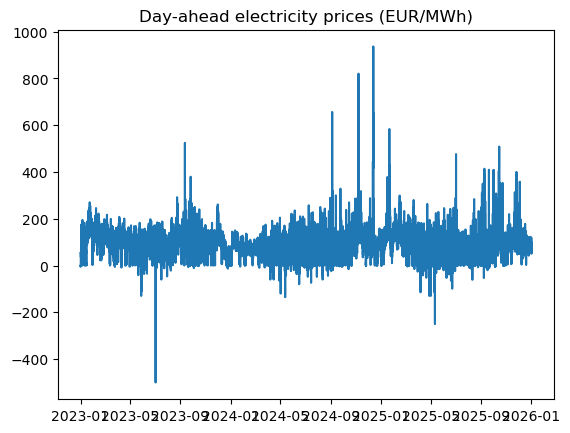

In [18]:
import matplotlib.pyplot as plt

plt.plot(prices_df.index, prices_df["price_eur_mwh"])
plt.title("Day-ahead electricity prices (EUR/MWh)")

### Deseasonalization — log-price (Paraschiv multiplicative decomposition)

Applies the log-price transformation $\tilde{S}_t = \log(S_t + \delta)$ with $\delta = 1000$ EUR/MWh. The seasonal component is:

$$\hat{s}_t = \bar{p} \cdot F2D_t \cdot F2Y_t$$

where $F2D_t$ is the intra-day factor (20 profile classes, hour dummies) and $F2Y_t$ is the annual factor (weekday + month dummies OLS on 2023-2025 daily averages). The deseasonalized residual $r_t^X = \tilde{S}_t - \hat{s}_t$ is stored in `german_panel.csv`.

In [19]:
import numpy as np
import pandas as pd

delta_shift = 1000.0

price_raw = prices_df["price_eur_mwh"].copy().sort_index().asfreq("h").interpolate(method="linear")
price = np.log(price_raw + delta_shift)

print("Log-price stats:")
print(price.describe())
print(f"\nMin raw price: {price_raw.min():.2f} EUR/MWh  =>  log({price_raw.min() + delta_shift:.1f}) = {np.log(price_raw.min() + delta_shift):.6f}")

# ============================================================
# Factor-to-day (F2D)
# f2d_t = price_t / daily_mean(price)  for each hour t
# Estimated separately for each of the 20 profile classes
# (weekday/weekend × season), using hour-of-day dummies.
# ============================================================
day_mean = price.resample("D").mean()
day_mean_per_hour = day_mean.reindex(price.index.floor("D")).to_numpy(dtype=float)
f2d = price.to_numpy(dtype=float) / day_mean_per_hour

idx   = price.index
dow   = idx.dayofweek
month = idx.month

# Assign each hour to one of 20 profile classes:
# weekday months 1-12 → classes 1-12; Saturday/Sunday × 4 seasons → classes 13-20
profile_class = np.zeros(len(idx), dtype=int)
for i in range(len(idx)):
    m = month[i]
    d = dow[i]
    if d <= 4:
        profile_class[i] = m
    elif d == 5:
        if m in [1, 2, 12]:   profile_class[i] = 13
        elif m in [3, 4, 5]:  profile_class[i] = 14
        elif m in [6, 7, 8]:  profile_class[i] = 15
        else:                  profile_class[i] = 16
    elif d == 6:
        if m in [1, 2, 12]:   profile_class[i] = 17
        elif m in [3, 4, 5]:  profile_class[i] = 18
        elif m in [6, 7, 8]:  profile_class[i] = 19
        else:                  profile_class[i] = 20

hour_dummies = pd.get_dummies(idx.hour, drop_first=True).astype(float)
X_base = np.column_stack([np.ones(len(idx)), hour_dummies.to_numpy()])

f2d_hat    = np.zeros(len(idx), dtype=float)
f2d_coeffs_by_class = {}
class_ids  = np.unique(profile_class)

for class_id in class_ids:
    mask        = (profile_class == class_id)
    X_class     = X_base[mask]
    price_class = price[mask].to_numpy()
    coeffs, *_  = np.linalg.lstsq(X_class, price_class, rcond=None)
    predicted   = X_class @ coeffs
    mean_shape  = np.mean(predicted)
    f2d_hat[mask] = predicted / mean_shape if mean_shape != 0 else 1.0
    f2d_coeffs_by_class[class_id] = (coeffs, mean_shape)

averageprice = price.mean()

Log-price stats:
count    26305.000000
mean         6.990761
std          0.046698
min          6.214608
25%          6.970730
50%          6.994043
75%          7.014832
max          7.568524
Name: price_eur_mwh, dtype: float64

Min raw price: -500.00 EUR/MWh  =>  log(500.0) = 6.214608


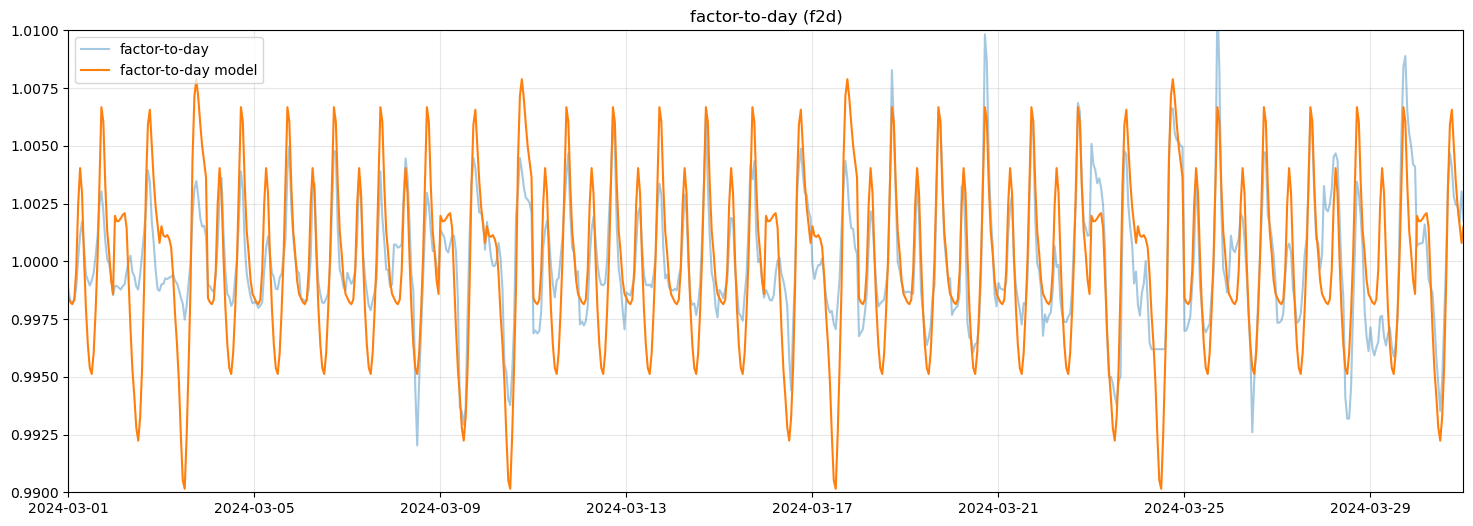

In [20]:
plt.figure(figsize=(18,6))
plt.plot(idx, f2d, alpha=0.4, label="factor-to-day")
plt.plot(idx, f2d_hat, label="factor-to-day model")

start_zoom = "2024-03-01"
end_zoom = "2024-03-31"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.ylim(0.99,1.01)
plt.title("factor-to-day (f2d)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#### Factor-to-year (F2Y) estimation

Regresses the daily mean log-price on weekday dummies and month dummies (August split into early/late halves). The fitted daily factor is broadcast to hourly frequency.

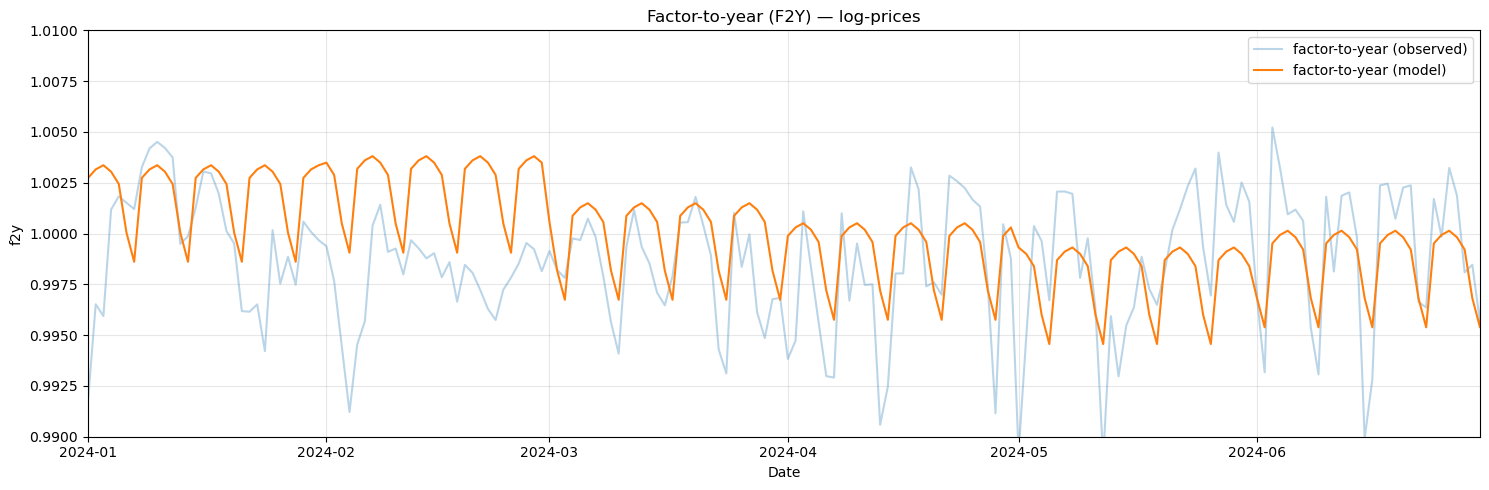

In [21]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

S_day    = price.resample("D").mean()
temp_day = temp.resample("D").mean()

combined_base = (
    pd.concat([S_day.rename("price_eur_mwh"), temp_day.rename("temperature_c")],
              axis=1, join="inner")
    .dropna()
)
S_day    = combined_base["price_eur_mwh"]
temp_day = combined_base["temperature_c"]

yearly_mean = S_day.groupby(S_day.index.year).transform("mean")
y = (S_day / yearly_mean).dropna()

X = pd.DataFrame(index=y.index)
for d, lbl in enumerate(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]):
    X[lbl] = (X.index.dayofweek == d).astype(int)
for m in range(2, 13):
    if m != 8:
        X[f"Month_{m}"] = (X.index.month == m).astype(int)
X["Aug_early"] = ((X.index.month == 8) & (X.index.day <= 15)).astype(int)
X["Aug_late"]  = ((X.index.month == 8) & (X.index.day  > 15)).astype(int)
X = sm.add_constant(X)

df_model   = pd.concat([y.rename("y"), X], axis=1).dropna()
y2, X2     = df_model["y"], df_model.drop(columns=["y"])
model_f2y  = sm.OLS(y2, X2).fit()
f2y_d_hat  = model_f2y.fittedvalues

plt.figure(figsize=(15, 5))
plt.plot(y2.index, y2, label="factor-to-year (observed)", alpha=0.3)
plt.plot(f2y_d_hat.index, f2y_d_hat, label="factor-to-year (model)")
plt.legend()
plt.xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2024-06-30"))
plt.ylim(0.99, 1.01)
plt.title("Factor-to-year (F2Y) — log-prices")
plt.xlabel("Date"); plt.ylabel("f2y")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Final seasonal component and deseasonalized log-price residuals

Combines the estimated factors into the full multiplicative seasonal component $\hat{s}_t = \bar{p} \cdot F2D_t \cdot F2Y_t$. The deseasonalized residual $r_t^X = \tilde{S}_t - \hat{s}_t$ is stored in `german_panel.csv`.

In [26]:
# Broadcast daily f2y to hourly: each hour inherits the value of its calendar day
daily_index = price.index.floor("D")
f2y_t_hat = f2y_d_hat.reindex(daily_index)

if f2y_t_hat.isna().any():
    missing_days = pd.Index(daily_index[f2y_t_hat.isna()]).unique()
    print(f"Warning: {len(missing_days)} daily F2Y values missing; filling by time interpolation.")
    f2y_t_hat = (
        f2y_d_hat
        .reindex(f2y_d_hat.index.union(daily_index))
        .sort_index()
        .interpolate(method="time")
        .ffill()
        .bfill()
        .reindex(daily_index)
    )

f2y_t_hat = pd.Series(f2y_t_hat.to_numpy(dtype=float), index=price.index, name="f2y_t_hat")

# Composite seasonal weight: sw_t = f2y_t * f2d_t
f2d_hat_s = pd.Series(np.asarray(f2d_hat, dtype=float), index=price.index, name="f2d_hat")
sw_t = f2y_t_hat * f2d_hat_s

yearly_avg = float(np.mean(price.values))

# Deterministic seasonal component: s_t = avg_log_price * sw_t
price_fit = (sw_t * yearly_avg).rename("log_price_seasonal")

# Deseasonalized log-price residual
price_resid = (price - price_fit).rename("price_deseasoned")

print("price_fit NaN:", int(price_fit.isna().sum()))
print("price_resid NaN:", int(price_resid.isna().sum()))
print("usable residuals:", int(price_resid.dropna().shape[0]))

price_fit NaN: 0
price_resid NaN: 0
usable residuals: 26305


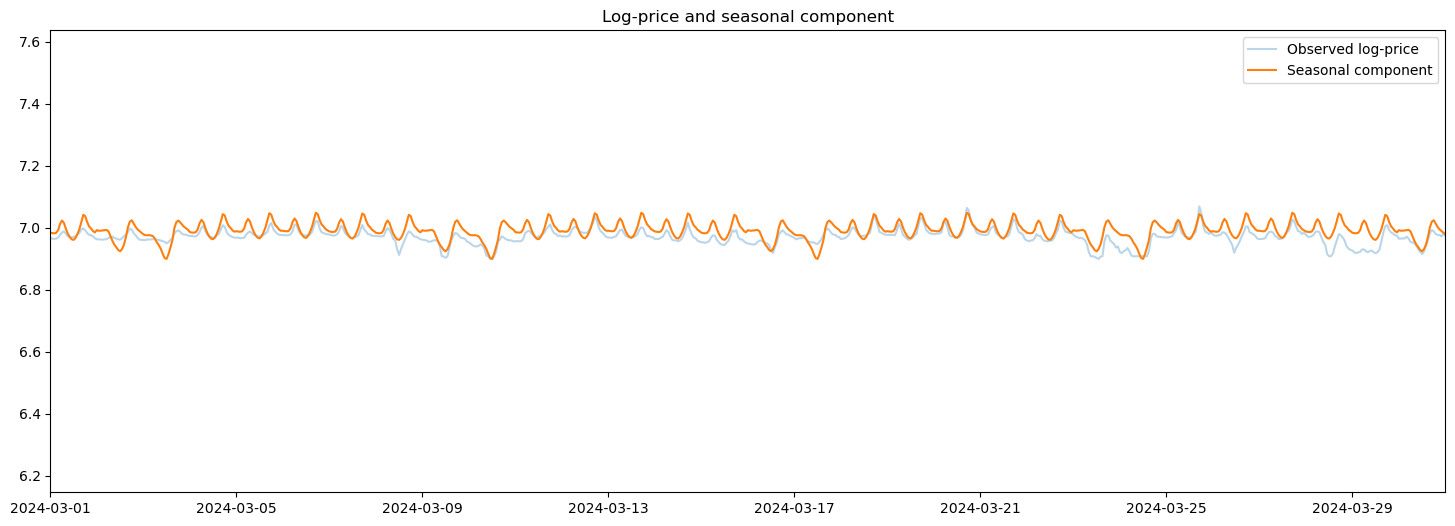

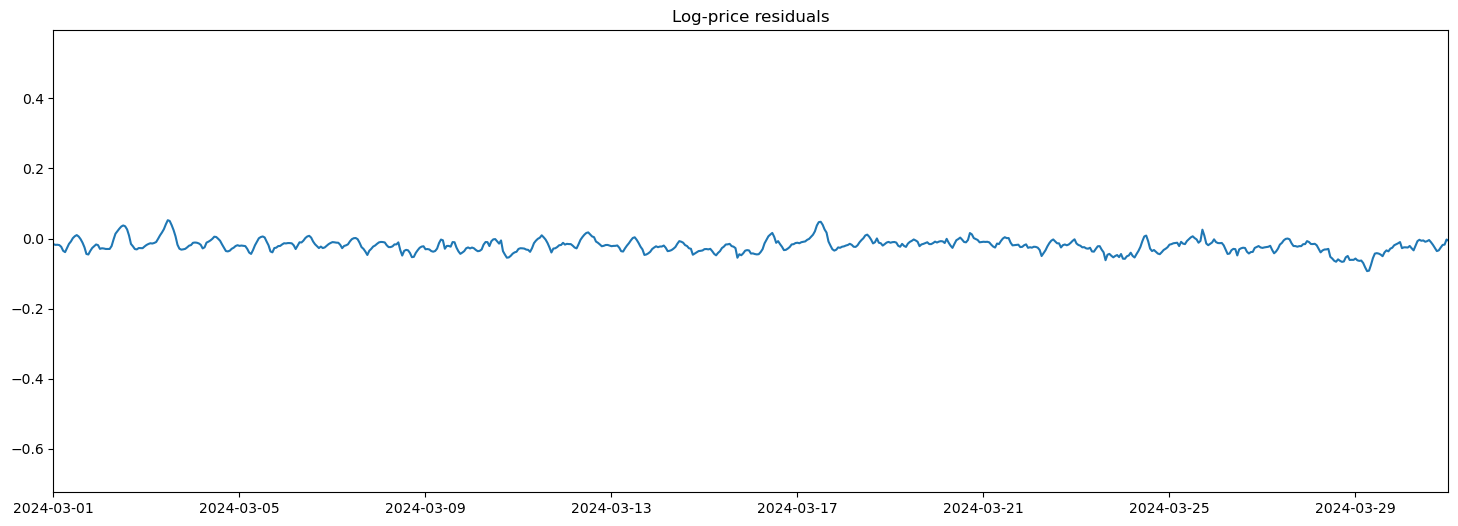

In [23]:
plt.figure(figsize=(18, 6))
plt.plot(price.index, price, alpha=0.3, label="Observed log-price")
plt.plot(price.index, price_fit, label="Seasonal component")
start_zoom = "2024-03-01"
end_zoom = "2024-03-31"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.title("Log-price and seasonal component")
plt.legend()

plt.figure(figsize=(18, 6))
plt.plot(idx, price_resid)
start_zoom = "2024-03-01"
end_zoom = "2024-03-31"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.title("Log-price residuals")
plt.show()

ACF input lengths: price=26,305, residual=26,305
Residual NaN count before drop: 0


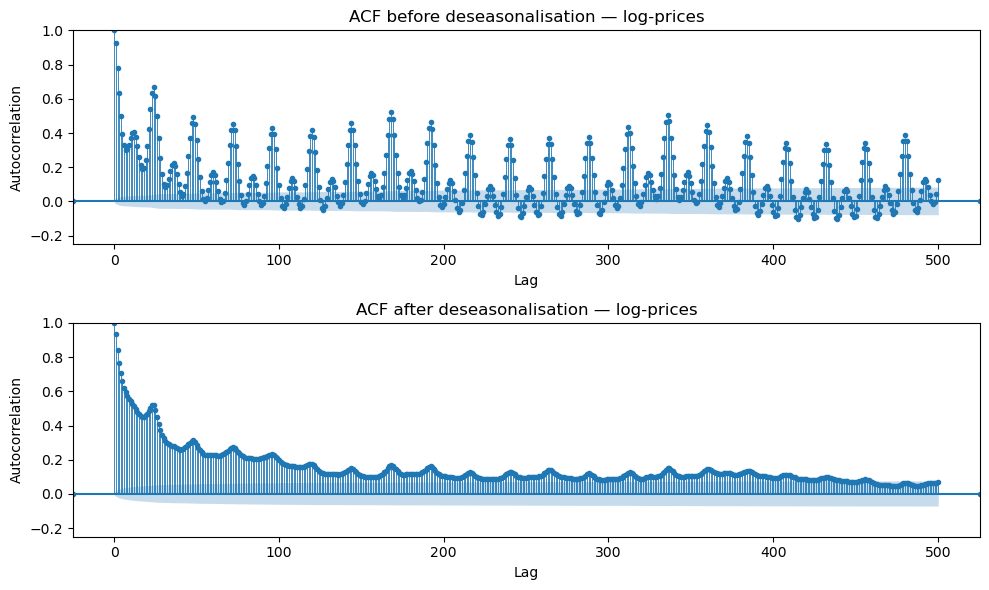

In [27]:
from statsmodels.graphics.tsaplots import plot_acf

price_acf = pd.Series(price).replace([np.inf, -np.inf], np.nan).dropna()
resid_acf = pd.Series(price_resid).replace([np.inf, -np.inf], np.nan).dropna()

print(f"ACF input lengths: price={len(price_acf):,}, residual={len(resid_acf):,}")
print(f"Residual NaN count before drop: {pd.Series(price_resid).isna().sum():,}")

if len(resid_acf) <= 1:
    raise ValueError("price_resid has too few non-NaN observations for ACF. Check price_fit/f2y_t_hat alignment.")

lags_price = min(500, len(price_acf) - 1)
lags_resid = min(500, len(resid_acf) - 1)

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(price_acf, lags=lags_price, ax=axs[0],
         vlines_kwargs={"linewidth": 0.6},
         marker="o", markersize=3)
axs[0].set_title("ACF before deseasonalisation — log-prices")
axs[0].set_ylabel("Autocorrelation")
axs[0].set_xlabel("Lag")

plot_acf(resid_acf, lags=lags_resid, ax=axs[1],
         vlines_kwargs={"linewidth": 0.6},
         marker="o", markersize=3)
axs[1].set_title("ACF after deseasonalisation — log-prices")
axs[1].set_ylabel("Autocorrelation")
axs[1].set_xlabel("Lag")

axs[0].set_ylim(-0.25, 1)
axs[1].set_ylim(-0.25, 1)

plt.tight_layout()
plt.show()

### Residual diagnostics — log-prices



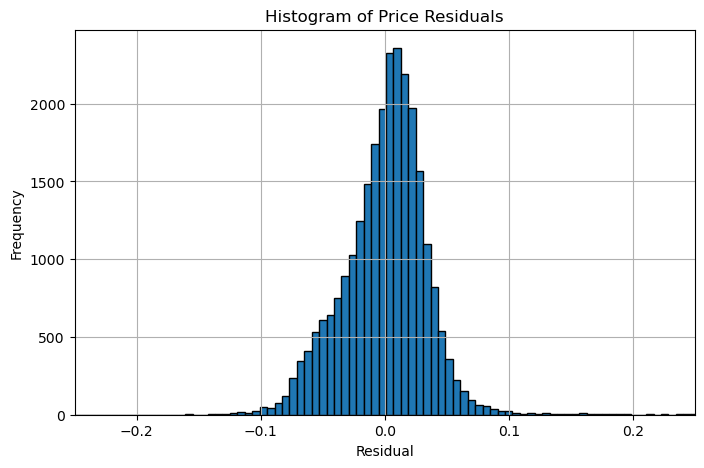

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(price_resid, bins=200, edgecolor="black")
plt.xlim(-0.25, 0.25)
plt.title("Histogram of Price Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(alpha=1)
plt.show()

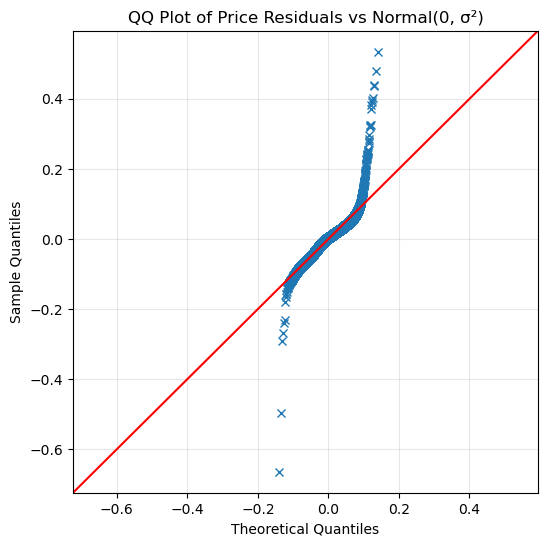

In [29]:
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot
import numpy as np
import matplotlib.pyplot as plt

# ensure Series
price_series = price_resid.squeeze()
 
 
plt.figure(figsize=(6, 6))
qqplot(price_series,
       dist=norm,
       loc=0,
       scale=np.std(price_series),
       line='45',
       marker='x',
       ax=plt.gca())

plt.title("QQ Plot of Price Residuals vs Normal(0, σ²)")
plt.grid(alpha=0.3)
plt.show()

In [30]:
price_series = price_resid.squeeze()
summary_stats_price = pd.DataFrame({
    "Value": [
        price_series.count(),
        price_series.mean(),
        price_series.std(),
        price_series.min(),
        price_series.quantile(0.25),
        price_series.median(),
        price_series.quantile(0.75),
        price_series.max(),
        stats.skew(price_series, bias=False),
        stats.kurtosis(price_series, fisher=True, bias=False)
    ]
}, index=[
    "Count",
    "Mean",
    "Std",
    "Min",
    "25%",
    "Median",
    "75%",
    "Max",
    "Skewness",
    "Excess Kurtosis"
])

print(summary_stats_price.round(4))

                      Value
Count            26305.0000
Mean                -0.0000
Std                  0.0355
Min                 -0.6644
25%                 -0.0193
Median               0.0034
75%                  0.0206
Max                  0.5345
Skewness             0.4632
Excess Kurtosis     17.8717


### Out-of-sample diagnostics — price seasonality (2026)

Applies the F2D and F2Y models fitted on 2023-2025 to 2026 log-prices (January-April). RMSE and MAE ratios close to 1 indicate the seasonal decomposition generalises well out of sample.

In [31]:
prices_raw_2026 = client.query_day_ahead_prices(
    ZONE,
    start=OOS_START,
    end=OOS_END_EXCLUSIVE,
)
price_raw_2026 = (
    prices_raw_2026.to_frame(name="price_eur_mwh")["price_eur_mwh"]
    .sort_index().tz_convert("UTC").asfreq("h").interpolate(method="linear")
)
price_2026 = np.log(price_raw_2026 + delta_shift)
start_str = str(price_2026.index[0].date())
end_str   = str(price_2026.index[-1].date())
print(f"2026 log-prices: {len(price_2026)} hourly observations ({start_str} to {end_str})")
print(price_2026.describe().round(4))

2026 log-prices: 2881 hourly observations (2026-01-01 to 2026-05-01)
count    2881.0000
mean        6.9995
std         0.0522
min         6.2538
25%         6.9870
50%         7.0056
75%         7.0257
max         7.1936
Name: price_eur_mwh, dtype: float64


NaN in resid_price_26: 0
=== Out-of-sample error metrics — log-price ===
      train (2023-25)  test (2026)  ratio (test/train)
RMSE           0.0355       0.0415              1.1702
MAE            0.0257       0.0294              1.1434
Std            0.0355       0.0414              1.1674
Mean          -0.0000       0.0029           6310.4022


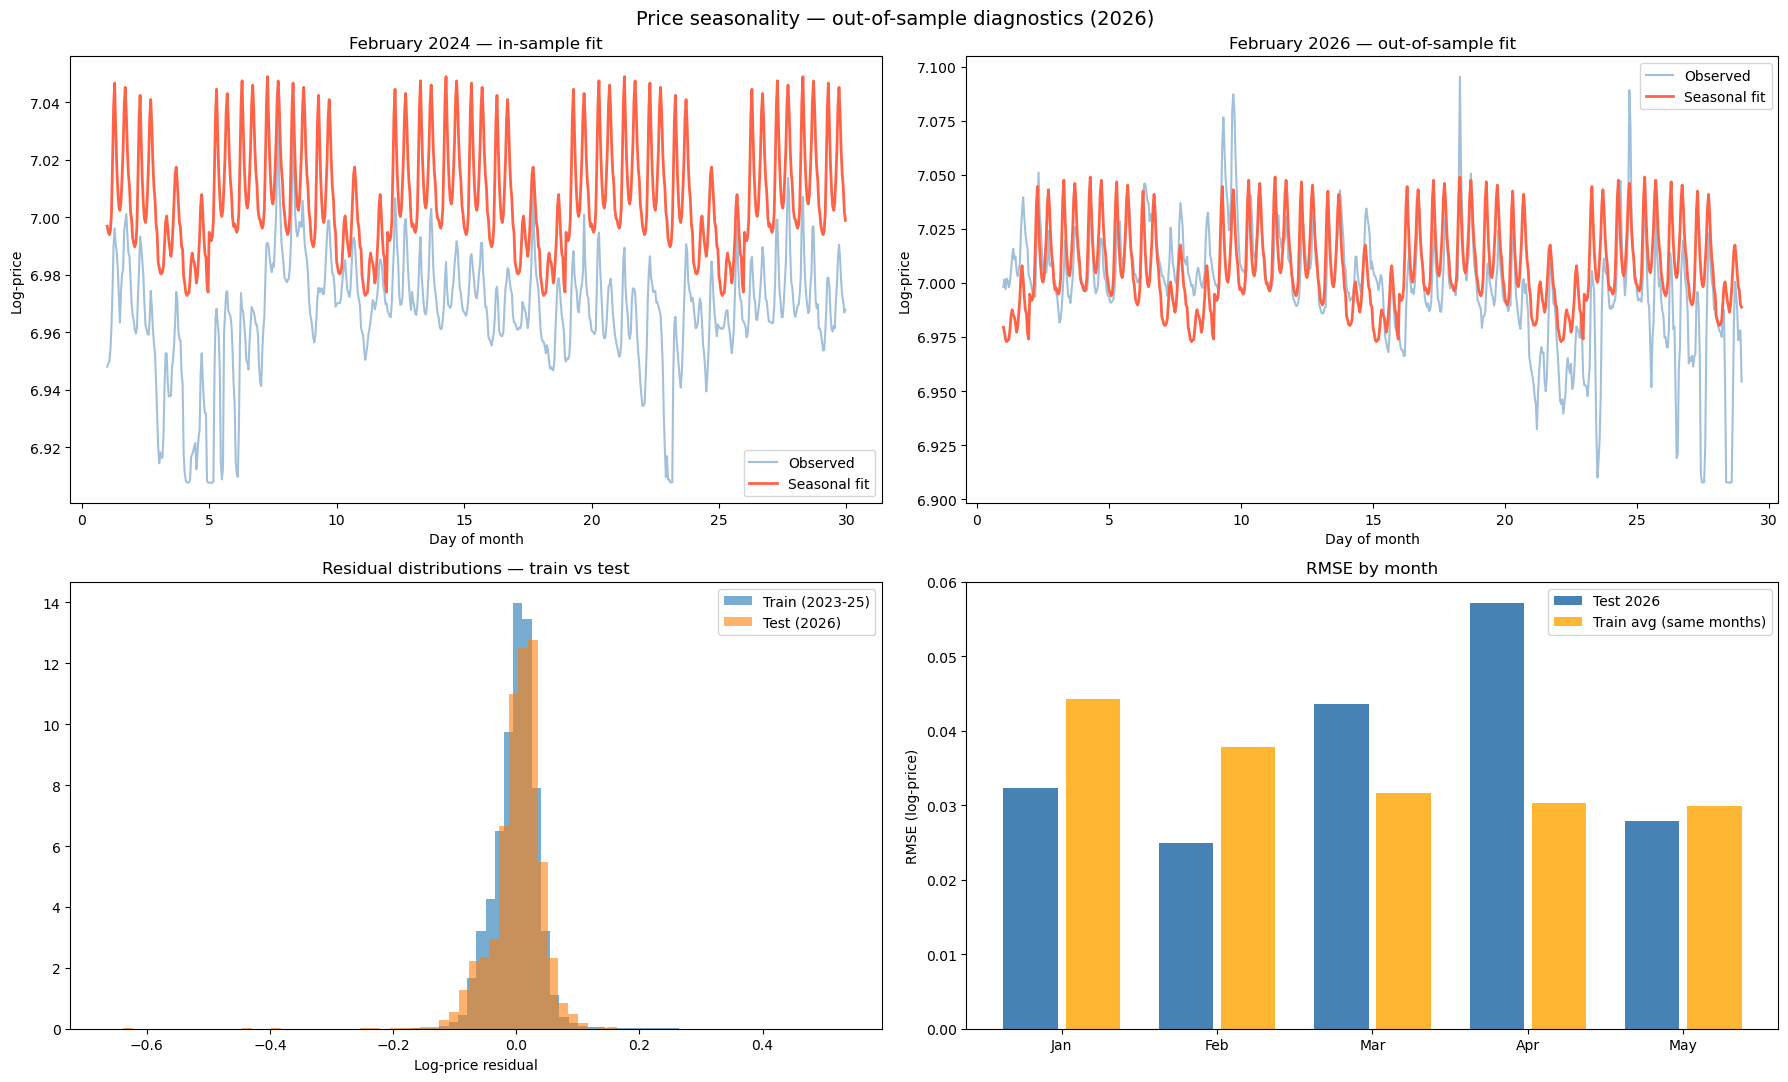

In [32]:
import statsmodels.api as sm
import calendar

# F2D for 2026 — assign profile classes, apply stored per-class coefficients
idx_26   = price_2026.index
dow_26   = idx_26.dayofweek
month_26 = idx_26.month

profile_class_26 = np.zeros(len(idx_26), dtype=int)
for i in range(len(idx_26)):
    m, d = month_26[i], dow_26[i]
    if d <= 4:
        profile_class_26[i] = m
    elif d == 5:
        profile_class_26[i] = 13 if m in [1,2,12] else 14 if m in [3,4,5] else 15 if m in [6,7,8] else 16
    else:
        profile_class_26[i] = 17 if m in [1,2,12] else 18 if m in [3,4,5] else 19 if m in [6,7,8] else 20

hour_dummies_26 = pd.get_dummies(idx_26.hour, drop_first=True).astype(float)
X_base_26 = np.column_stack([np.ones(len(idx_26)), hour_dummies_26.to_numpy()])

f2d_hat_26 = np.zeros(len(idx_26), dtype=float)
for cid in np.unique(profile_class_26):
    mask = profile_class_26 == cid
    if cid in f2d_coeffs_by_class:
        c26, ms26 = f2d_coeffs_by_class[cid]
        pred = X_base_26[mask] @ c26
        f2d_hat_26[mask] = pred / ms26 if ms26 != 0 else 1.0
    else:
        f2d_hat_26[mask] = 1.0

# F2Y for 2026 — build daily regressors, predict with model_f2y
temp_day_26  = temp_2026.resample("D").mean()
price_day_26 = price_2026.resample("D").mean()

X26 = pd.DataFrame(index=price_day_26.index)
for d26, lbl in enumerate(["Mon","Tue","Wed","Thu","Fri","Sat"]):
    X26[lbl] = (X26.index.dayofweek == d26).astype(int)
for m26 in range(2, 13):
    if m26 != 8:
        X26[f"Month_{m26}"] = (X26.index.month == m26).astype(int)
X26["Aug_early"] = ((X26.index.month == 8) & (X26.index.day <= 15)).astype(int)
X26["Aug_late"]  = ((X26.index.month == 8) & (X26.index.day  > 15)).astype(int)
X26 = sm.add_constant(X26)
X26 = X26.reindex(columns=model_f2y.model.exog_names, fill_value=0)

f2y_d_26       = model_f2y.predict(X26)
daily_index_26 = price_2026.index.normalize()
f2y_t_26       = f2y_d_26.reindex(daily_index_26).values

price_fit_26   = pd.Series(f2y_t_26 * f2d_hat_26 * yearly_avg, index=price_2026.index)
resid_price_26 = (price_2026 - price_fit_26).dropna()

print(f"NaN in resid_price_26: {(price_2026 - price_fit_26).isna().sum()}")

metrics_df = pd.DataFrame({
    "train (2023-25)": {
        "RMSE": _rmse(price_resid),
        "MAE":  _mae(price_resid),
        "Std":  float(price_resid.std()),
        "Mean": float(price_resid.mean()),
    },
    "test (2026)": {
        "RMSE": _rmse(resid_price_26),
        "MAE":  _mae(resid_price_26),
        "Std":  float(resid_price_26.std()),
        "Mean": float(resid_price_26.mean()),
    },
})
metrics_df["ratio (test/train)"] = (
    metrics_df["test (2026)"].abs() / metrics_df["train (2023-25)"].abs()
)
print("=== Out-of-sample error metrics — log-price ===")
print(metrics_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle("Price seasonality — out-of-sample diagnostics (2026)", fontsize=14)

feb24_p_mask = (price.index.month == 2) & (price.index.year == 2024)
price_feb24  = price[feb24_p_mask]
fit_feb24_p  = price_fit[feb24_p_mask]
days24p = price_feb24.index.day + price_feb24.index.hour / 24

feb26_p_mask = price_2026.index.month == 2
price_feb26  = price_2026[feb26_p_mask]
fit_feb26_p  = price_fit_26[feb26_p_mask]
days26p = price_feb26.index.day + price_feb26.index.hour / 24

axes[0, 0].plot(days24p, price_feb24.values, alpha=0.5, label="Observed", color="steelblue")
axes[0, 0].plot(days24p, fit_feb24_p.values, linewidth=2, label="Seasonal fit", color="tomato")
axes[0, 0].set_title("February 2024 — in-sample fit", fontsize=12)
axes[0, 0].set_xlabel("Day of month"); axes[0, 0].set_ylabel("Log-price"); axes[0, 0].legend()

axes[0, 1].plot(days26p, price_feb26.values, alpha=0.5, label="Observed", color="steelblue")
axes[0, 1].plot(days26p, fit_feb26_p.values, linewidth=2, label="Seasonal fit", color="tomato")
axes[0, 1].set_title("February 2026 — out-of-sample fit", fontsize=12)
axes[0, 1].set_xlabel("Day of month"); axes[0, 1].set_ylabel("Log-price"); axes[0, 1].legend()

axes[1, 0].hist(price_resid.values, bins=80, alpha=0.6, density=True, label="Train (2023-25)")
axes[1, 0].hist(resid_price_26.values, bins=50, alpha=0.6, density=True, label="Test (2026)")
axes[1, 0].set_title("Residual distributions — train vs test", fontsize=12)
axes[1, 0].legend(); axes[1, 0].set_xlabel("Log-price residual")

tr_idx_p = pd.to_datetime(price_resid.index)
rmse_train_by_month_p = (
    pd.Series(price_resid.values, index=tr_idx_p)
    .groupby(tr_idx_p.month)
    .apply(_rmse)
)
rmse_26_by_month_p = resid_price_26.groupby(resid_price_26.index.month).apply(_rmse)
common_m = rmse_26_by_month_p.index
axes[1, 1].bar(common_m - 0.2, rmse_26_by_month_p.values, width=0.35, label="Test 2026", color="steelblue")
axes[1, 1].bar(rmse_train_by_month_p.reindex(common_m).index + 0.2,
               rmse_train_by_month_p.reindex(common_m).values, width=0.35,
               label="Train avg (same months)", color="orange", alpha=0.8)
axes[1, 1].set_xticks(common_m)
axes[1, 1].set_xticklabels([calendar.month_abbr[m] for m in common_m])
axes[1, 1].set_title("RMSE by month", fontsize=12)
axes[1, 1].set_ylabel("RMSE (log-price)"); axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [33]:
import pandas as pd
import numpy as np
from pathlib import Path

SEAS_DIR = DATA_DIR / "seasonality"
SEAS_DIR.mkdir(parents=True, exist_ok=True)

# ── german_panel.csv : calibration period (2023-2025) ─────────────────────────
temp_seasonal_s = pd.Series(temp_fit, index=temp.index)

panel = pd.DataFrame({
    "price_raw":          price_raw.reindex(price.index),
    "log_price":          price,
    "log_price_seasonal": price_fit,
    "log_price_resid":    price_resid,
    "temp_raw":           temp.reindex(price.index),
    "temp_seasonal":      temp_seasonal_s.reindex(price.index),
    "temp_resid":         temp_resid.reindex(price.index),
})
panel.index.name = "datetime"
panel.to_csv(SEAS_DIR / "german_panel.csv")
print(f"Saved german_panel.csv : {len(panel):,} rows × {panel.shape[1]} columns")
print(panel.head(3))

Saved german_panel.csv : 26,305 rows × 7 columns
                           price_raw  log_price  log_price_seasonal  \
datetime                                                              
2023-01-01 00:00:00+00:00      -1.07   6.906685            6.976389   
2023-01-01 01:00:00+00:00      -1.47   6.906284            6.973910   
2023-01-01 02:00:00+00:00      -5.08   6.902662            6.970693   

                           log_price_resid  temp_raw  temp_seasonal  \
datetime                                                              
2023-01-01 00:00:00+00:00        -0.069705     15.25       2.023784   
2023-01-01 01:00:00+00:00        -0.067625     15.65       2.032819   
2023-01-01 02:00:00+00:00        -0.068031     15.70       2.015470   

                           temp_resid  
datetime                               
2023-01-01 00:00:00+00:00   13.226216  
2023-01-01 01:00:00+00:00   13.617181  
2023-01-01 02:00:00+00:00   13.684530  


In [34]:
# ── german_panel_2026.csv : out-of-sample (2026-01 to 2026-04) ───────────────
temp_seasonal_2026 = pd.Series(fit_2026, index=temp_2026.index)

panel_2026 = pd.DataFrame({
    "price_raw":          price_raw_2026.reindex(price_2026.index),
    "log_price":          price_2026,
    "log_price_seasonal": price_fit_26,
    "log_price_resid":    (price_2026 - price_fit_26),
    "temp_raw":           temp_2026.reindex(price_2026.index),
    "temp_seasonal":      temp_seasonal_2026.reindex(price_2026.index),
    "temp_resid":         resid_2026.reindex(price_2026.index),
})
panel_2026.index.name = "datetime"
panel_2026.to_csv(SEAS_DIR / "german_panel_2026.csv")
print(f"Saved german_panel_2026.csv : {len(panel_2026):,} rows × {panel_2026.shape[1]} columns")
print(panel_2026.head(3))

Saved german_panel_2026.csv : 2,881 rows × 7 columns
                           price_raw  log_price  log_price_seasonal  \
datetime                                                              
2026-01-01 00:00:00+00:00      60.01   6.966034            6.980802   
2026-01-01 01:00:00+00:00      36.01   6.943132            6.978465   
2026-01-01 02:00:00+00:00      10.08   6.917785            6.975050   

                           log_price_resid  temp_raw  temp_seasonal  \
datetime                                                              
2026-01-01 00:00:00+00:00        -0.014768      2.35       1.075625   
2026-01-01 01:00:00+00:00        -0.035332      2.90       1.084679   
2026-01-01 02:00:00+00:00        -0.057265      2.95       1.067363   

                           temp_resid  
datetime                               
2026-01-01 00:00:00+00:00    1.274375  
2026-01-01 01:00:00+00:00    1.815321  
2026-01-01 02:00:00+00:00    1.882637  
